CARGANDO SIMULADOR DE CADENAS DE MARKOV...

SIMULADOR DE CADENAS DE MARKOV
1. Ejemplo simple (clima - 3 estados)
2. Ejemplo con estado absorbente (graduación)
3. Ejemplo complejo (comportamiento cliente - 4 estados)
4. Ingresar mi propia cadena
5. Salir

EJEMPLO 1: CADENA DE MARKOV SIMPLE (3 ESTADOS)
ANÁLISIS DE CADENA DE MARKOV

1. INFORMACIÓN BÁSICA:
   Número de estados: 3
   Estados: ['Soleado', 'Nublado', 'Lluvioso']

2. MATRIZ DE TRANSICIÓN:
   Soleado: [0.7 0.2 0.1]
   Nublado: [0.3 0.5 0.2]
   Lluvioso: [0.2 0.3 0.5]

3. DISTRIBUCIÓN ESTACIONARIA:
   Soleado: 0.4634 (46.3%)
   Nublado: 0.3171 (31.7%)
   Lluvioso: 0.2195 (22.0%)

4. TIEMPOS MEDIOS DE RETORNO:
   Soleado: 2.16 pasos
   Nublado: 3.15 pasos
   Lluvioso: 4.56 pasos

5. PROPIEDADES:
   ✓ La cadena es IRREDUCIBLE
   ✓ La cadena es APERIÓDICA

6. DISTRIBUCIÓN DESPUÉS DE 5 DÍAS (comienza nublado):
   Soleado: 0.4583
   Nublado: 0.3194
   Lluvioso: 0.2223

7. GRÁFICO DE EVOLUCIÓN (se abrirá ventana)...


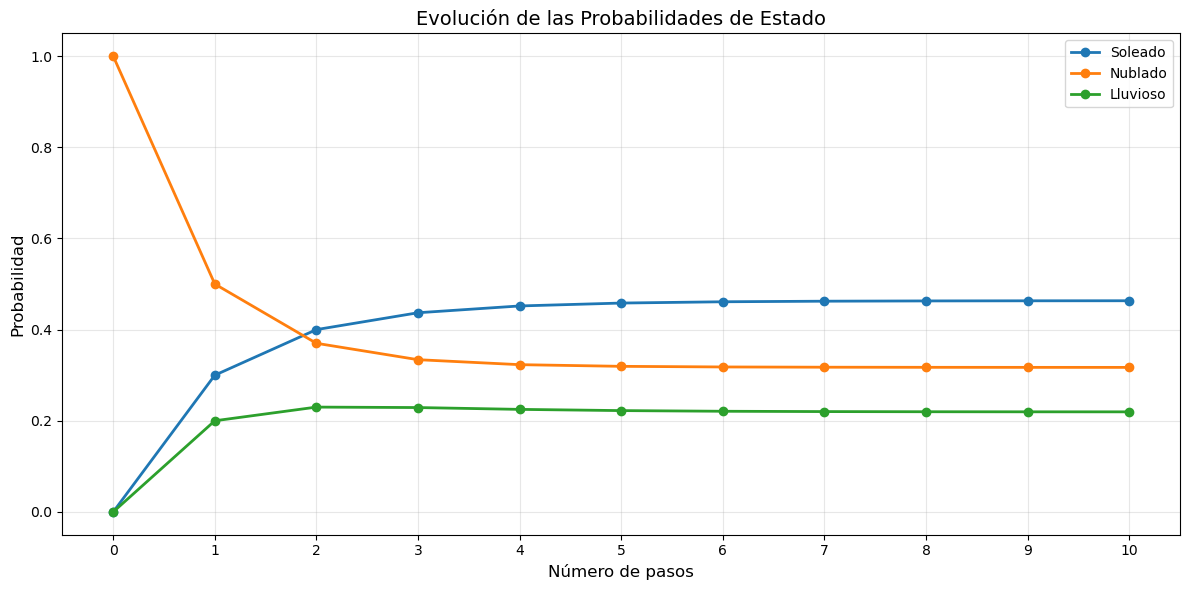


SIMULADOR DE CADENAS DE MARKOV
1. Ejemplo simple (clima - 3 estados)
2. Ejemplo con estado absorbente (graduación)
3. Ejemplo complejo (comportamiento cliente - 4 estados)
4. Ingresar mi propia cadena
5. Salir

EJEMPLO 2: CADENA CON ESTADO ABSORBENTE

Distribuciones a lo largo del tiempo:
  Año 1: Estudiante=0.7000, Graduado=0.3000
  Año 2: Estudiante=0.4900, Graduado=0.5100
  Año 5: Estudiante=0.1681, Graduado=0.8319
  Año 10: Estudiante=0.0282, Graduado=0.9718
  Año 20: Estudiante=0.0008, Graduado=0.9992

Distribución estacionaria:
  Estudiante: 0.0000
  Graduado: 1.0000

Tiempo medio hasta graduación: 3.33 años

SIMULADOR DE CADENAS DE MARKOV
1. Ejemplo simple (clima - 3 estados)
2. Ejemplo con estado absorbente (graduación)
3. Ejemplo complejo (comportamiento cliente - 4 estados)
4. Ingresar mi propia cadena
5. Salir

EJEMPLO 2: CADENA CON ESTADO ABSORBENTE

Distribuciones a lo largo del tiempo:
  Año 1: Estudiante=0.7000, Graduado=0.3000
  Año 2: Estudiante=0.4900, Graduado=0.510

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_17248\1247471157.py:162: RuntimeWarning: divide by zero encountered in divide
  tiempos = 1 / pi_estable


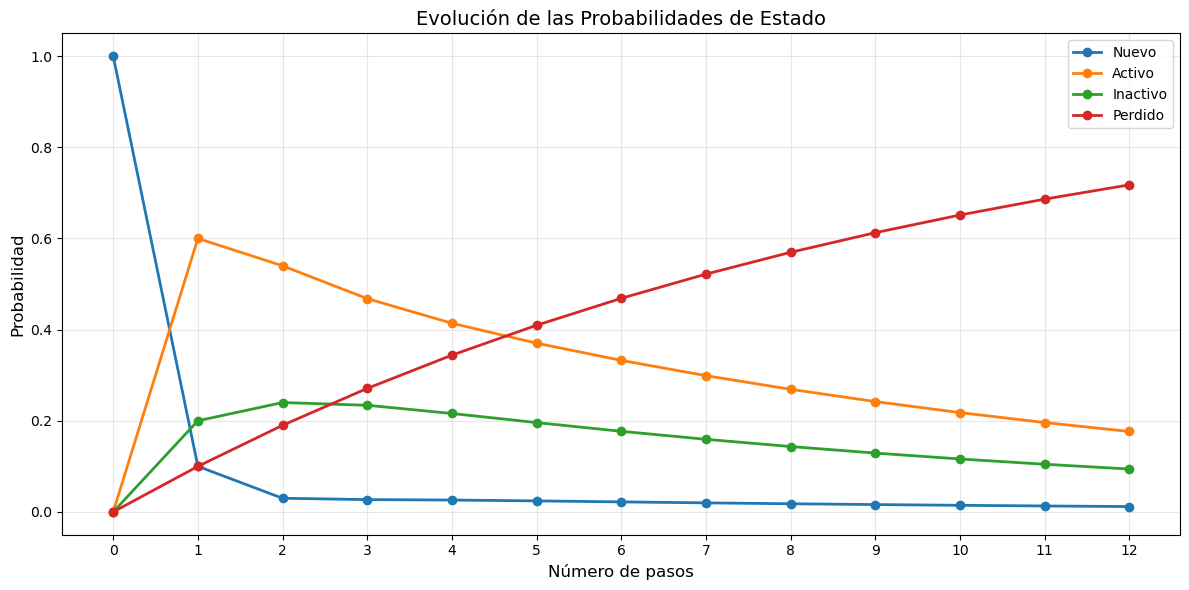


SIMULADOR DE CADENAS DE MARKOV
1. Ejemplo simple (clima - 3 estados)
2. Ejemplo con estado absorbente (graduación)
3. Ejemplo complejo (comportamiento cliente - 4 estados)
4. Ingresar mi propia cadena
5. Salir

¡Hasta luego!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg

class CadenaMarkov:
    def __init__(self, matriz_transicion, estados=None):
        """
        Inicializa una cadena de Markov
        
        Args:
            matriz_transicion: Matriz de transición (n x n)
            estados: Nombres de los estados (opcional)
        """
        self.P = np.array(matriz_transicion, dtype=float)
        self.n_estados = self.P.shape[0]
        
        # Verificar que es matriz de transición válida
        self._verificar_matriz()
        
        # Nombres de estados
        if estados is None:
            self.estados = [f"E{i+1}" for i in range(self.n_estados)]
        else:
            self.estados = estados
    
    def _verificar_matriz(self):
        """Verifica que la matriz sea estocástica"""
        # Verificar dimensiones
        if self.P.shape[0] != self.P.shape[1]:
            raise ValueError("La matriz debe ser cuadrada")
        
        # Verificar que las filas sumen 1
        suma_filas = np.sum(self.P, axis=1)
        if not np.allclose(suma_filas, 1.0):
            raise ValueError("Las filas deben sumar 1")
        
        # Verificar que todos los valores estén entre 0 y 1
        if np.any(self.P < 0) or np.any(self.P > 1):
            raise ValueError("Las probabilidades deben estar entre 0 y 1")
    
    def distribucion_n_pasos(self, pi0, n):
        """
        Calcula la distribución después de n pasos
        
        Args:
            pi0: Vector de distribución inicial
            n: Número de pasos
            
        Returns:
            Vector de distribución después de n pasos
        """
        pi0 = np.array(pi0, dtype=float)
        # Normalizar pi0 si es necesario
        if not np.isclose(np.sum(pi0), 1.0):
            pi0 = pi0 / np.sum(pi0)
        
        # Calcular P^n
        P_n = np.linalg.matrix_power(self.P, n)
        
        # Distribución después de n pasos
        pi_n = pi0 @ P_n
        
        return pi_n
    
    def estado_estable(self, metodo='autovector', max_iter=1000, tol=1e-10):
        """
        Calcula la distribución estacionaria/estable
        
        Args:
            metodo: 'autovector' o 'iterativo'
            max_iter: Máximo de iteraciones para método iterativo
            tol: Tolerancia para convergencia
            
        Returns:
            Distribución estacionaria
        """
        if metodo == 'autovector':
            # Método 1: Autovector izquierdo con autovalor 1
            # Encontrar autovectores de P^T
            valores, vectores = np.linalg.eig(self.P.T)
            
            # Encontrar índice del autovalor 1 (o más cercano a 1)
            idx = np.argmin(np.abs(valores - 1.0))
            
            # Obtener el autovector correspondiente
            pi_estable = np.real(vectores[:, idx])
            
            # Normalizar para que sume 1
            pi_estable = pi_estable / np.sum(pi_estable)
            
        elif metodo == 'iterativo':
            # Método 2: Iteración hasta convergencia
            pi = np.ones(self.n_estados) / self.n_estados  # Distribución inicial uniforme
            
            for i in range(max_iter):
                pi_nuevo = pi @ self.P
                
                # Verificar convergencia
                if np.linalg.norm(pi_nuevo - pi) < tol:
                    pi = pi_nuevo
                    break
                
                pi = pi_nuevo
                
            pi_estable = pi
        else:
            raise ValueError("Método debe ser 'autovector' o 'iterativo'")
        
        return pi_estable
    
    def tiempo_primer_paso(self, estado_inicial, estado_objetivo, max_pasos=100):
        """
        Calcula probabilidades de primer paso
        
        Args:
            estado_inicial: Índice del estado inicial
            estado_objetivo: Índice del estado objetivo
            max_pasos: Máximo número de pasos a calcular
            
        Returns:
            Array con probabilidades de primer paso para cada n
        """
        f = np.zeros(max_pasos + 1)
        f[1] = self.P[estado_inicial, estado_objetivo]
        
        for n in range(2, max_pasos + 1):
            suma = 0
            for k in range(self.n_estados):
                if k != estado_objetivo:
                    suma += self.P[estado_inicial, k] * self._calcular_f(n-1, k, estado_objetivo, max_pasos)
            f[n] = suma
        
        return f
    
    def _calcular_f(self, n, i, j, max_pasos, memo=None):
        """Función auxiliar recursiva con memoización"""
        if memo is None:
            memo = {}
        
        if (n, i, j) in memo:
            return memo[(n, i, j)]
        
        if n == 1:
            resultado = self.P[i, j]
        else:
            resultado = 0
            for k in range(self.n_estados):
                if k != j:
                    resultado += self.P[i, k] * self._calcular_f(n-1, k, j, max_pasos, memo)
        
        memo[(n, i, j)] = resultado
        return resultado
    
    def tiempo_medio_retorno(self):
        """
        Calcula tiempos medios de retorno a cada estado
        
        Returns:
            Array con tiempos medios de retorno
        """
        pi_estable = self.estado_estable()
        tiempos = 1 / pi_estable
        return tiempos
    
    def analizar_cadena(self):
        """Realiza análisis completo de la cadena"""
        print("=" * 60)
        print("ANÁLISIS DE CADENA DE MARKOV")
        print("=" * 60)
        
        # 1. Información básica
        print(f"\n1. INFORMACIÓN BÁSICA:")
        print(f"   Número de estados: {self.n_estados}")
        print(f"   Estados: {self.estados}")
        
        # 2. Matriz de transición
        print(f"\n2. MATRIZ DE TRANSICIÓN:")
        for i, fila in enumerate(self.P):
            print(f"   {self.estados[i]}: {fila}")
        
        # 3. Distribución estacionaria
        pi_estable = self.estado_estable()
        print(f"\n3. DISTRIBUCIÓN ESTACIONARIA:")
        for i, prob in enumerate(pi_estable):
            print(f"   {self.estados[i]}: {prob:.4f} ({prob*100:.1f}%)")
        
        # 4. Tiempos medios de retorno
        tiempos = self.tiempo_medio_retorno()
        print(f"\n4. TIEMPOS MEDIOS DE RETORNO:")
        for i, t in enumerate(tiempos):
            print(f"   {self.estados[i]}: {t:.2f} pasos")
        
        # 5. Verificar periodicidad
        print(f"\n5. PROPIEDADES:")
        if self._es_irreducible():
            print("   ✓ La cadena es IRREDUCIBLE")
        else:
            print("   ✗ La cadena es REDUCIBLE")
        
        if self._es_aperiodica():
            print("   ✓ La cadena es APERIÓDICA")
        else:
            print("   ✗ La cadena es PERIÓDICA")
        
        print("=" * 60)
        
        return {
            'estacionaria': pi_estable,
            'tiempos_retorno': tiempos,
            'irreducible': self._es_irreducible(),
            'aperiodica': self._es_aperiodica()
        }
    
    def _es_irreducible(self):
        """Verifica si la cadena es irreducible"""
        # Calcular matriz de accesibilidad
        accesible = np.zeros((self.n_estados, self.n_estados), dtype=bool)
        
        # Sumar P + P^2 + ... + P^n
        P_sum = np.zeros((self.n_estados, self.n_estados))
        P_potencia = np.eye(self.n_estados)
        
        for _ in range(self.n_estados):
            P_potencia = P_potencia @ self.P
            P_sum += P_potencia
        
        # Si todos los elementos son > 0, es irreducible
        accesible = P_sum > 0
        
        return np.all(accesible)
    
    def _es_aperiodica(self):
        """Verifica si la cadena es aperiódica"""
        # Método simplificado: verificar si hay auto-bucles con probabilidad > 0
        for i in range(self.n_estados):
            if self.P[i, i] > 0:
                return True
        return False
    
    def simular(self, pi0, pasos=20):
        """
        Simula una trayectoria de la cadena
        
        Args:
            pi0: Distribución inicial
            pasos: Número de pasos a simular
            
        Returns:
            Lista con la secuencia de estados
        """
        # Normalizar pi0
        pi0 = np.array(pi0, dtype=float)
        if not np.isclose(np.sum(pi0), 1.0):
            pi0 = pi0 / np.sum(pi0)
        
        # Estado inicial
        estado_actual = np.random.choice(self.n_estados, p=pi0)
        trayectoria = [estado_actual]
        
        # Simular pasos siguientes
        for _ in range(pasos - 1):
            # Elegir próximo estado según distribución de la fila actual
            proximo_estado = np.random.choice(
                self.n_estados, 
                p=self.P[estado_actual]
            )
            trayectoria.append(proximo_estado)
            estado_actual = proximo_estado
        
        return trayectoria
    
    def graficar_evolucion(self, pi0, max_pasos=10):
        """
        Grafica la evolución de las probabilidades
        
        Args:
            pi0: Distribución inicial
            max_pasos: Número máximo de pasos a graficar
        """
        # Calcular distribuciones para cada paso
        distribuciones = []
        pi_actual = np.array(pi0, dtype=float)
        if not np.isclose(np.sum(pi_actual), 1.0):
            pi_actual = pi_actual / np.sum(pi_actual)
        
        distribuciones.append(pi_actual)
        
        for paso in range(1, max_pasos + 1):
            pi_actual = pi_actual @ self.P
            distribuciones.append(pi_actual)
        
        distribuciones = np.array(distribuciones)
        
        # Crear gráfico
        fig, ax = plt.subplots(figsize=(12, 6))
        
        for i in range(self.n_estados):
            ax.plot(range(max_pasos + 1), 
                   distribuciones[:, i], 
                   marker='o', 
                   label=self.estados[i], 
                   linewidth=2)
        
        ax.set_xlabel('Número de pasos', fontsize=12)
        ax.set_ylabel('Probabilidad', fontsize=12)
        ax.set_title('Evolución de las Probabilidades de Estado', fontsize=14)
        ax.grid(True, alpha=0.3)
        ax.legend()
        ax.set_xticks(range(max_pasos + 1))
        
        plt.tight_layout()
        plt.show()
        
        return distribuciones


# ============================================================================
# EJEMPLOS DE USO
# ============================================================================

def ejemplo_simple():
    """Ejemplo 1: Cadena de Markov simple de 3 estados"""
    print("\n" + "="*60)
    print("EJEMPLO 1: CADENA DE MARKOV SIMPLE (3 ESTADOS)")
    print("="*60)
    
    # Definir matriz de transición (ejemplo: clima)
    P = [
        [0.7, 0.2, 0.1],  # Soleado → Soleado, Nublado, Lluvioso
        [0.3, 0.5, 0.2],  # Nublado → Soleado, Nublado, Lluvioso
        [0.2, 0.3, 0.5]   # Lluvioso → Soleado, Nublado, Lluvioso
    ]
    
    estados = ["Soleado", "Nublado", "Lluvioso"]
    
    # Crear cadena de Markov
    cadena = CadenaMarkov(P, estados)
    
    # Analizar completamente
    resultados = cadena.analizar_cadena()
    
    # Calcular distribuciones específicas
    pi0 = [0, 1, 0]  # Comienza nublado
    
    print("\n6. DISTRIBUCIÓN DESPUÉS DE 5 DÍAS (comienza nublado):")
    pi5 = cadena.distribucion_n_pasos(pi0, 5)
    for i, (estado, prob) in enumerate(zip(estados, pi5)):
        print(f"   {estado}: {prob:.4f}")
    
    # Graficar evolución
    print("\n7. GRÁFICO DE EVOLUCIÓN (se abrirá ventana)...")
    cadena.graficar_evolucion(pi0, max_pasos=10)
    
    return cadena, resultados

def ejemplo_absorbente():
    """Ejemplo 2: Cadena con estado absorbente"""
    print("\n" + "="*60)
    print("EJEMPLO 2: CADENA CON ESTADO ABSORBENTE")
    print("="*60)
    
    # Estados: 0=Estudiante, 1=Graduado (absorbente)
    P = [
        [0.7, 0.3],  # Estudiante → Estudiante, Graduado
        [0.0, 1.0]   # Graduado → Graduado, Graduado
    ]
    
    estados = ["Estudiante", "Graduado"]
    
    cadena = CadenaMarkov(P, estados)
    
    # Distribución inicial: 100% estudiante
    pi0 = [1, 0]
    
    print("\nDistribuciones a lo largo del tiempo:")
    for n in [1, 2, 5, 10, 20]:
        pi_n = cadena.distribucion_n_pasos(pi0, n)
        print(f"  Año {n}: Estudiante={pi_n[0]:.4f}, Graduado={pi_n[1]:.4f}")
    
    print("\nDistribución estacionaria:")
    pi_estable = cadena.estado_estable()
    for i, (estado, prob) in enumerate(zip(estados, pi_estable)):
        print(f"  {estado}: {prob:.4f}")
    
    # Tiempo medio hasta graduación
    print(f"\nTiempo medio hasta graduación: {1/P[0][1]:.2f} años")
    
    return cadena

def ejemplo_complejo():
    """Ejemplo 3: Cadena más compleja (4 estados)"""
    print("\n" + "="*60)
    print("EJEMPLO 3: CADENA COMPLEJA (4 ESTADOS) - Comportamiento cliente")
    print("="*60)
    
    # Estados de un cliente: 0=Nuevo, 1=Activo, 2=Inactivo, 3=Perdido
    P = [
        [0.1, 0.6, 0.2, 0.1],  # Nuevo
        [0.0, 0.7, 0.2, 0.1],  # Activo
        [0.1, 0.3, 0.5, 0.1],  # Inactivo
        [0.0, 0.0, 0.0, 1.0]   # Perdido (absorbente)
    ]
    
    estados = ["Nuevo", "Activo", "Inactivo", "Perdido"]
    
    cadena = CadenaMarkov(P, estados)
    
    # Análisis completo
    cadena.analizar_cadena()
    
    # Simulación
    print("\nSimulación de trayectoria (20 meses):")
    pi0 = [1, 0, 0, 0]  # Cliente nuevo
    trayectoria = cadena.simular(pi0, pasos=20)
    
    # Convertir índices a nombres de estados
    trayectoria_nombres = [estados[i] for i in trayectoria]
    print("  Trayectoria:", " → ".join(trayectoria_nombres))
    
    # Graficar evolución
    print("\nGráfico de evolución (se abrirá ventana)...")
    cadena.graficar_evolucion(pi0, max_pasos=12)
    
    return cadena

def ejemplo_personalizado():
    """Interfaz para que el usuario ingrese su propia cadena"""
    print("\n" + "="*60)
    print("EJEMPLO PERSONALIZADO")
    print("="*60)
    
    # Solicitar número de estados
    n = int(input("¿Cuántos estados tiene tu cadena? (2-5): "))
    
    estados = []
    for i in range(n):
        nombre = input(f"Nombre del estado {i+1}: ")
        estados.append(nombre)
    
    # Solicitar matriz de transición
    print("\nIngresa la matriz de transición (filas deben sumar 1):")
    P = []
    for i in range(n):
        print(f"\nProbabilidades desde estado '{estados[i]}':")
        fila = []
        for j in range(n):
            prob = float(input(f"  Probabilidad de ir a '{estados[j]}': "))
            fila.append(prob)
        
        # Verificar que la fila suma 1
        if not np.isclose(sum(fila), 1.0):
            print("  ¡ADVERTENCIA! La fila no suma 1. Normalizando...")
            fila = [p/sum(fila) for p in fila]
        
        P.append(fila)
    
    # Crear cadena
    cadena = CadenaMarkov(P, estados)
    
    # Distribución inicial
    print(f"\nDistribución inicial (suma debe ser 1):")
    pi0 = []
    for i, estado in enumerate(estados):
        prob = float(input(f"  Probabilidad inicial para '{estado}': "))
        pi0.append(prob)
    
    if not np.isclose(sum(pi0), 1.0):
        print("  Normalizando distribución inicial...")
        pi0 = [p/sum(pi0) for p in pi0]
    
    # Análisis
    cadena.analizar_cadena()
    
    # Calcular para pasos específicos
    n_pasos = int(input("\n¿Para cuántos pasos quieres calcular la distribución? "))
    pi_n = cadena.distribucion_n_pasos(pi0, n_pasos)
    
    print(f"\nDistribución después de {n_pasos} pasos:")
    for estado, prob in zip(estados, pi_n):
        print(f"  {estado}: {prob:.4f} ({prob*100:.1f}%)")
    
    return cadena

def menu_principal():
    """Menú interactivo principal"""
    while True:
        print("\n" + "="*60)
        print("SIMULADOR DE CADENAS DE MARKOV")
        print("="*60)
        print("1. Ejemplo simple (clima - 3 estados)")
        print("2. Ejemplo con estado absorbente (graduación)")
        print("3. Ejemplo complejo (comportamiento cliente - 4 estados)")
        print("4. Ingresar mi propia cadena")
        print("5. Salir")
        print("="*60)
        
        opcion = input("\nSelecciona una opción (1-5): ")
        
        if opcion == '1':
            cadena, _ = ejemplo_simple()
            
            # Preguntar si quiere guardar resultados
            if input("\n¿Guardar resultados en CSV? (s/n): ").lower() == 's':
                guardar_resultados(cadena)
                
        elif opcion == '2':
            cadena = ejemplo_absorbente()
            
        elif opcion == '3':
            cadena = ejemplo_complejo()
            
        elif opcion == '4':
            cadena = ejemplo_personalizado()
            
        elif opcion == '5':
            print("\n¡Hasta luego!")
            break
            
        else:
            print("\nOpción no válida. Intenta de nuevo.")

def guardar_resultados(cadena, archivo="resultados_markov.csv"):
    """Guarda los resultados en un archivo CSV"""
    import pandas as pd
    
    # Crear DataFrame con la matriz de transición
    df_matriz = pd.DataFrame(
        cadena.P,
        index=[f"Desde {e}" for e in cadena.estados],
        columns=[f"Hacia {e}" for e in cadena.estados]
    )
    
    # Distribución estacionaria
    pi_estable = cadena.estado_estable()
    df_estacionaria = pd.DataFrame({
        'Estado': cadena.estados,
        'Probabilidad_Estacionaria': pi_estable,
        'Porcentaje': pi_estable * 100
    })
    
    # Guardar en Excel con múltiples hojas
    with pd.ExcelWriter('resultados_markov.xlsx') as writer:
        df_matriz.to_excel(writer, sheet_name='Matriz_Transicion')
        df_estacionaria.to_excel(writer, sheet_name='Distribucion_Estacionaria')
    
    print(f"\nResultados guardados en 'resultados_markov.xlsx'")

# ============================================================================
# EJECUCIÓN PRINCIPAL
# ============================================================================

if __name__ == "__main__":
    print("CARGANDO SIMULADOR DE CADENAS DE MARKOV...")
    
    # Ejecutar menú interactivo
    menu_principal()
    
    # O ejecutar ejemplos directamente
    # ejemplo_simple()
    # ejemplo_absorbente()
    # ejemplo_complejo()